## Improving SIRENs for Image Representation: Learning Rate Scheduling, Shortcut Connections, and Self-Attention

---
- Baseline Code Link: https://github.com/vsitzmann/siren

### 1. Import and GPU Setting

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import os

from PIL import Image
from torchvision.transforms import Resize, Compose, ToTensor, Normalize
import numpy as np
import skimage
import matplotlib.pyplot as plt

import time
import math

In [2]:
# use GPU
device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")

device: mps


### 2. Generate Coordinate Grids

In [3]:
def get_mgrid(sidelen, dim=2):
    tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
    mgrid = torch.stack(torch.meshgrid(*tensors), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid

### 3. Building Block of SIREN

In [4]:
class SineLayer(nn.Module):
    
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()
    
    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0, np.sqrt(6 / self.in_features) / self.omega_0)
        
    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))

In [5]:
class SelfAttention(nn.Module):
    
    def __init__(self, embed_size):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size

        self.values = nn.Linear(self.embed_size, self.embed_size, bias=False)
        self.keys = nn.Linear(self.embed_size, self.embed_size, bias=False)
        self.queries = nn.Linear(self.embed_size, self.embed_size, bias=False)
        self.fc_out = nn.Linear(self.embed_size, self.embed_size)

    def forward(self, values, keys, queries):
        values = values.reshape(256, 256)
        keys = keys.reshape(256, 256)
        queries = queries.reshape(256, 256)

        values  = self.values(values)
        keys    = self.keys(keys)
        queries = self.queries(queries)

        # Self attention
        energy = torch.matmul(queries, keys.transpose(0, 1))
        attention = F.softmax(energy, dim=1)

        out = torch.matmul(attention, values)
        out = self.fc_out(out)

        return out

In [6]:
class SirenWithAttention(nn.Module):
    
    def __init__(self, in_features, hidden_features, hidden_layers, out_features, outermost_linear=False, first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, is_first=True, omega_0=first_omega_0))
        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=hidden_omega_0))
        
        self.attention = SelfAttention(embed_size=hidden_features)
        
        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / hidden_omega_0, np.sqrt(6 / hidden_features) / hidden_omega_0)
            self.net.append(final_linear)
        else:
            self.net.append(SineLayer(hidden_features, out_features, is_first=False, omega_0=hidden_omega_0))
        
        self.net = nn.Sequential(*self.net)
    
    def forward(self, coords):
        coords = coords.clone().detach().requires_grad_(True)
        output = coords
        for layer in self.net:
            output = layer(output)
        output = self.attention(output, output, output)
            
        return output, coords

### 4. Gradients and Laplacian

In [7]:
def laplace(y, x):
    grad = gradient(y, x)
    return divergence(grad, x)


def divergence(y, x):
    div = 0.
    for i in range(y.shape[-1]):
        div += torch.autograd.grad(y[..., i], x, torch.ones_like(y[..., i]), create_graph=True)[0][..., i:i+1]
    return div


def gradient(y, x, grad_outputs=None):
    if grad_outputs is None:
        grad_outputs = torch.ones_like(y)
    grad = torch.autograd.grad(y, [x], grad_outputs=grad_outputs, create_graph=True)[0]
    return grad

### 5. Fitting an Image

In [8]:
def get_cameraman_tensor(sidelength):
    img = Image.fromarray(skimage.data.camera())        
    transform = Compose([
        Resize(sidelength),
        ToTensor(),
        Normalize(torch.Tensor([0.5]), torch.Tensor([0.5]))
    ])
    img = transform(img)
    return img

In [9]:
class ImageFitting(Dataset):
    
    def __init__(self, sidelength):
        super().__init__()
        img = get_cameraman_tensor(sidelength)
        self.pixels = img.permute(1, 2, 0).view(-1, 1)
        self.coords = get_mgrid(sidelength, 2)

    def __len__(self):
        return 1

    def __getitem__(self, idx):    
        if idx > 0: raise IndexError
            
        return self.coords, self.pixels

In [10]:
cameraman = ImageFitting(256)
dataloader = DataLoader(cameraman, batch_size=1, pin_memory=True, num_workers=0)

img_siren = SirenWithAttention(in_features=2, out_features=1, hidden_features=256, hidden_layers=3, outermost_linear=True)
img_siren.to(device)

/Users/hayleyshin/opt/anaconda3/lib/python3.9/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


SirenWithAttention(
  (attention): SelfAttention(
    (values): Linear(in_features=256, out_features=256, bias=False)
    (keys): Linear(in_features=256, out_features=256, bias=False)
    (queries): Linear(in_features=256, out_features=256, bias=False)
    (fc_out): Linear(in_features=256, out_features=256, bias=True)
  )
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=2, out_features=256, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

Step 0, Total loss 0.323213


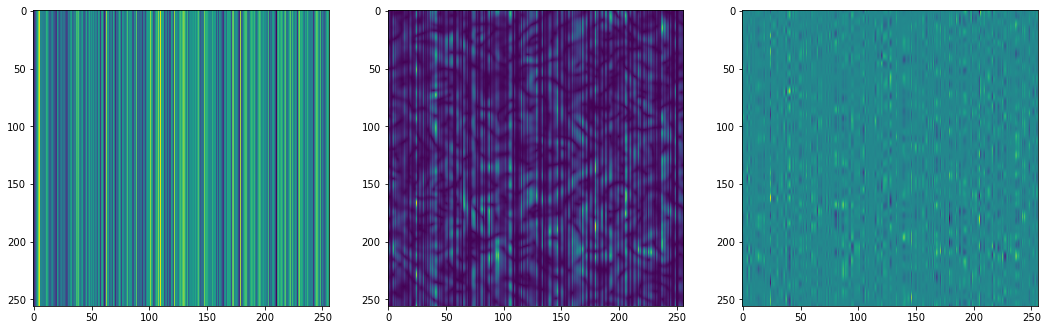

Step 10, Total loss 0.309560


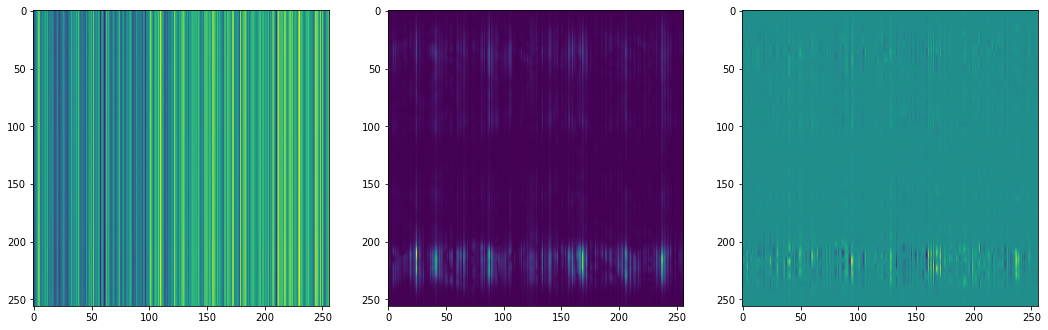

Step 20, Total loss 0.274460


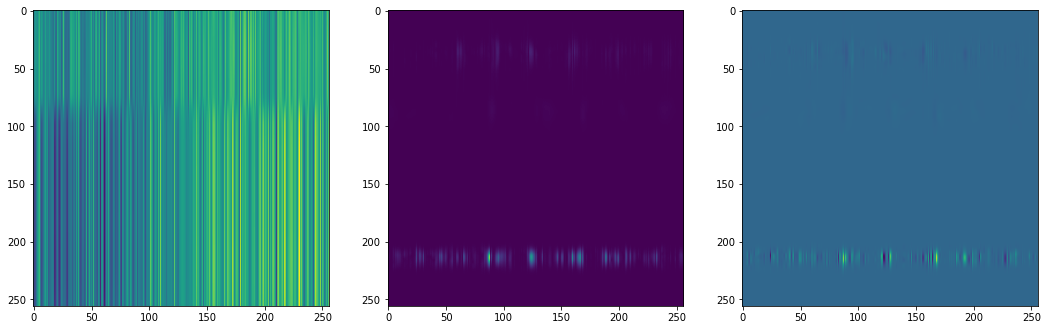

Step 30, Total loss 0.223779


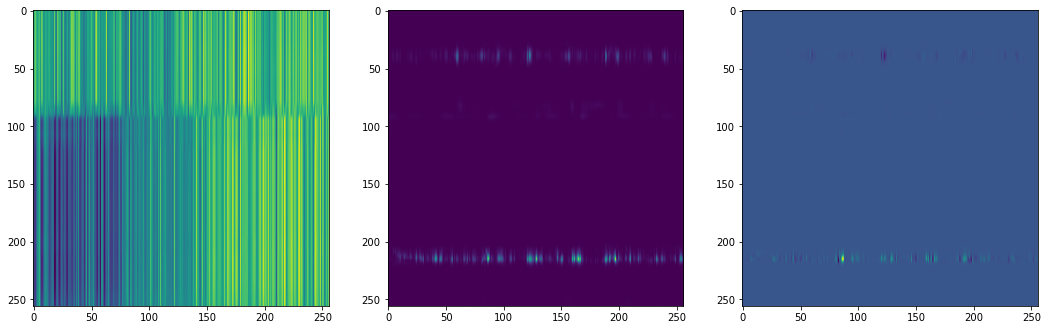

Step 40, Total loss 0.162682


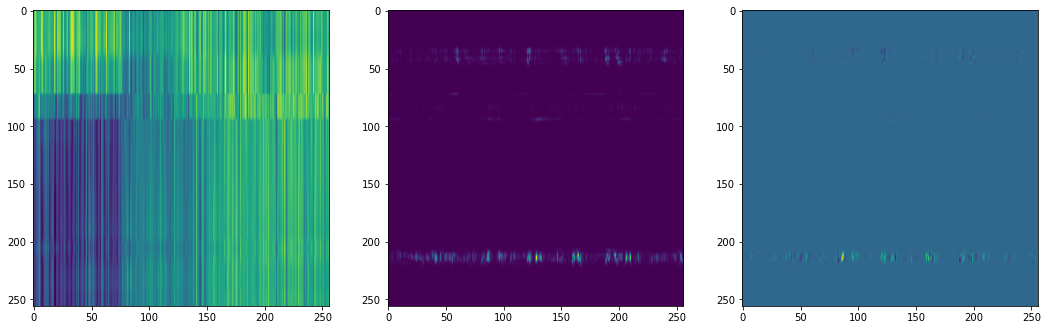

Step 50, Total loss 0.118385


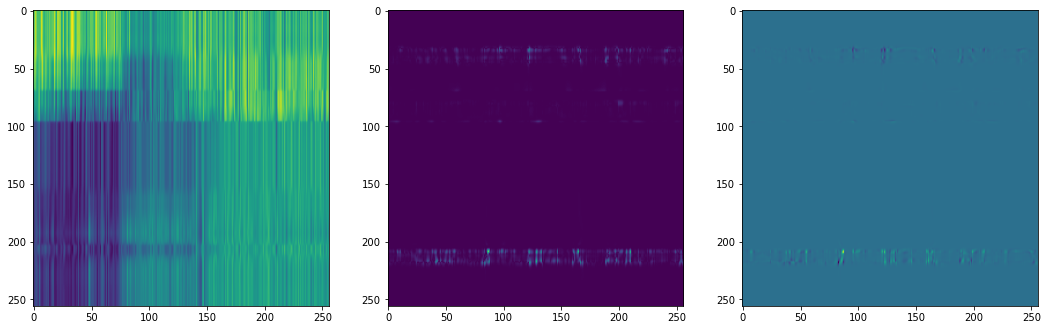

Step 60, Total loss 0.092810


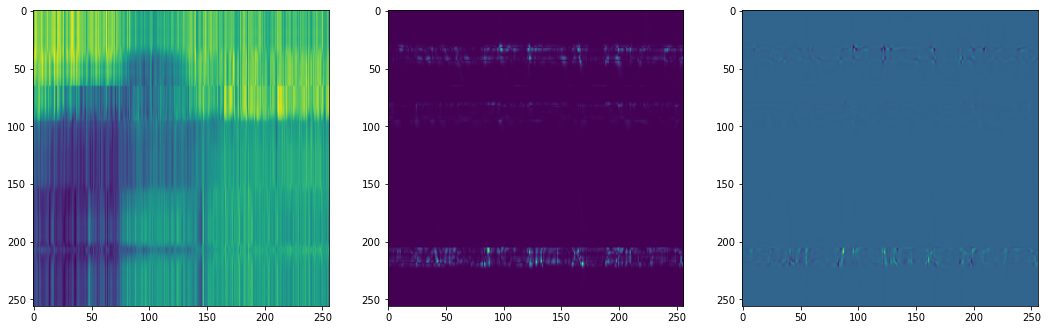

Step 70, Total loss 0.073679


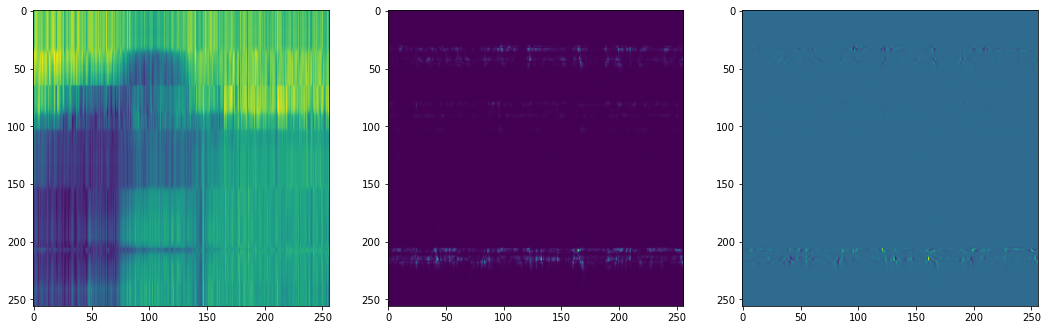

Step 80, Total loss 0.059522


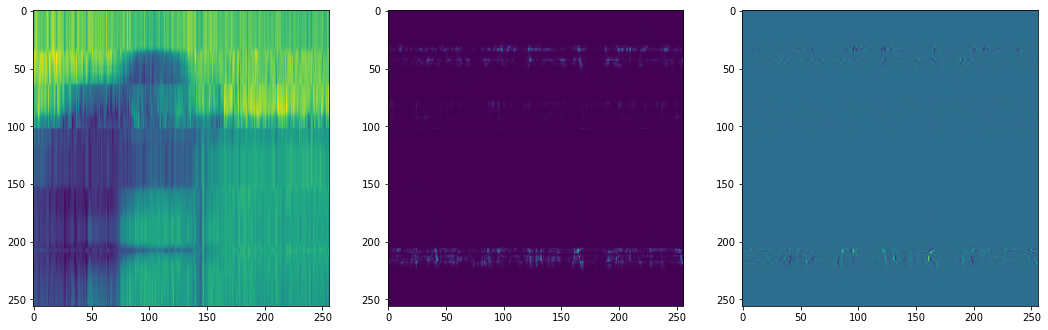

Step 90, Total loss 0.050062


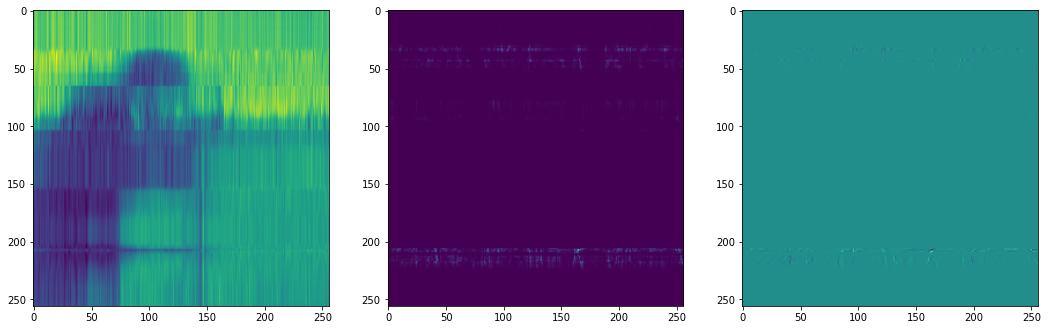

Step 100, Total loss 0.043291


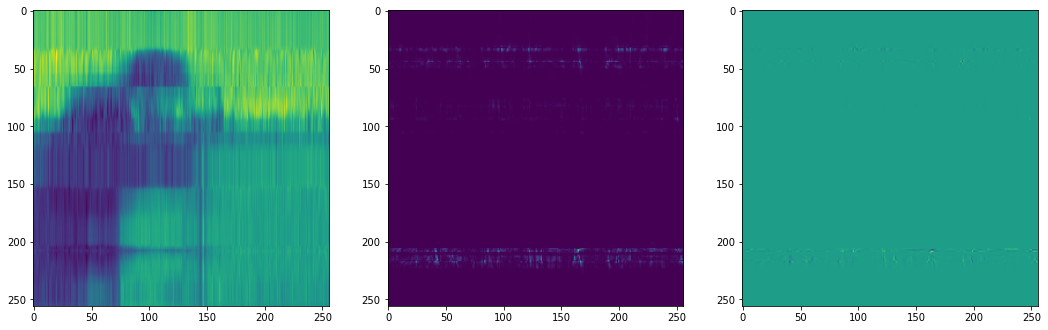

Step 110, Total loss 0.039956


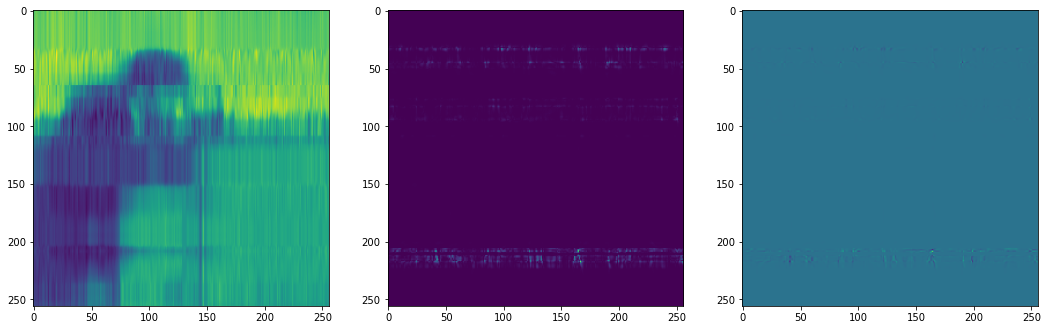

Step 120, Total loss 0.035800


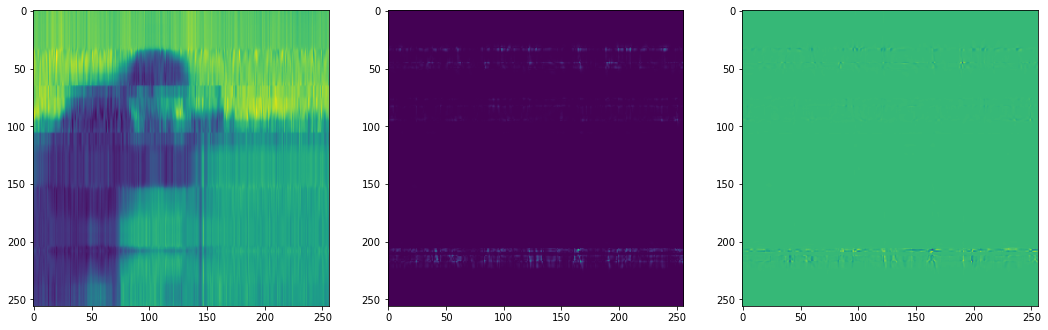

Step 130, Total loss 0.032506


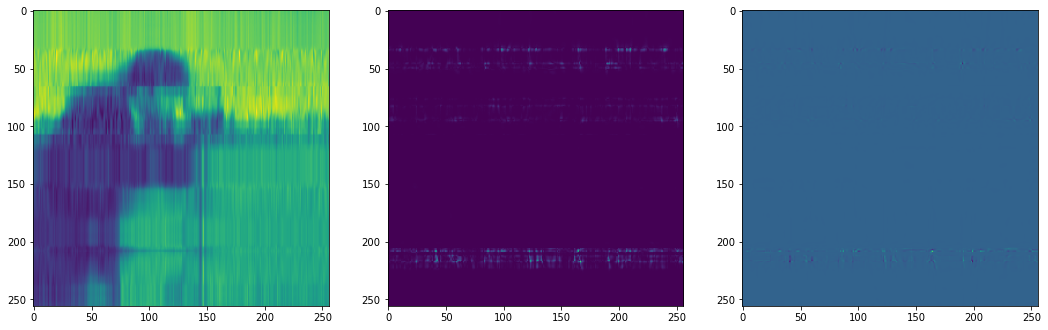

Step 140, Total loss 0.038482


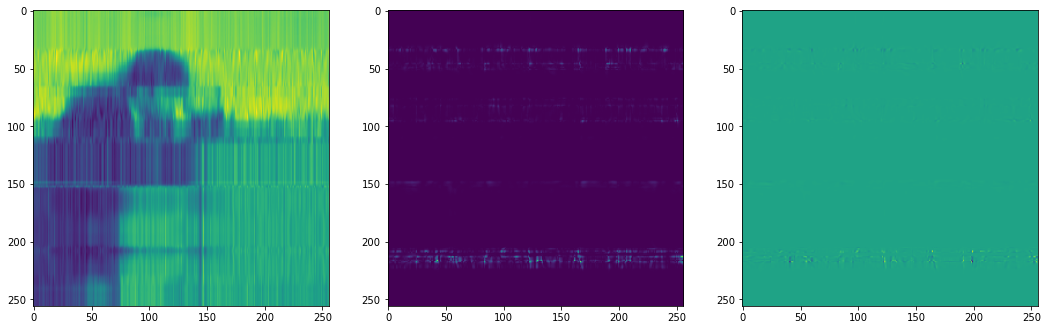

Step 150, Total loss 0.034964


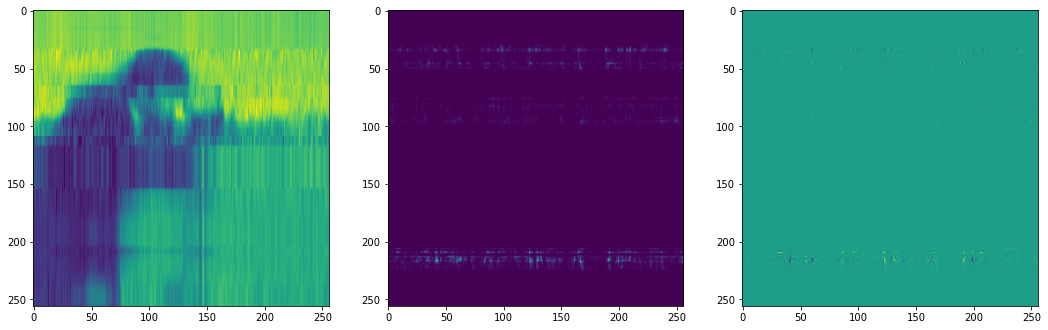

Step 160, Total loss 0.034041


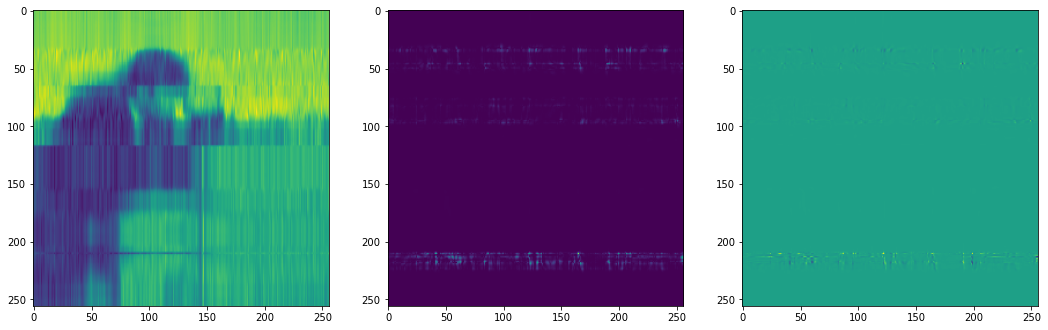

Step 170, Total loss 0.034598


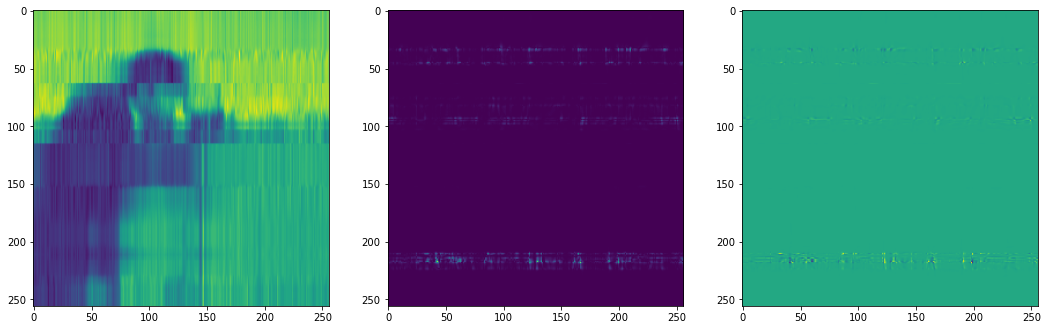

Step 180, Total loss 0.029901


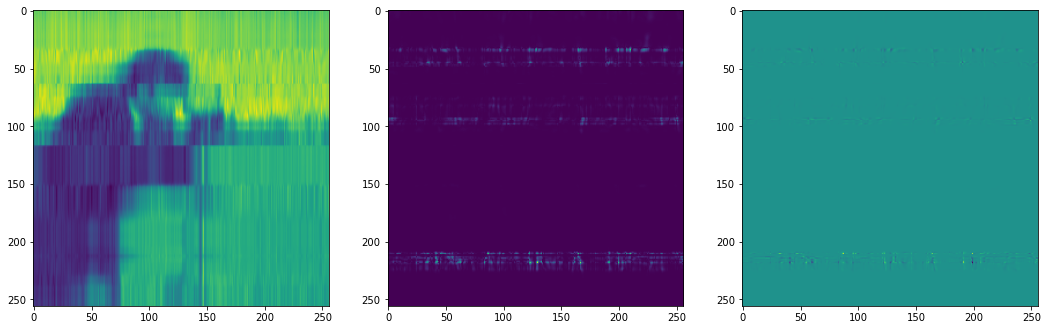

Step 190, Total loss 0.028050


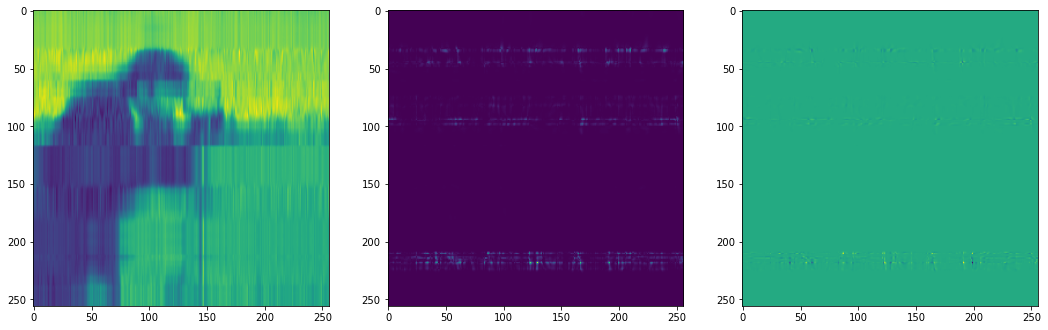

Step 200, Total loss 0.026844


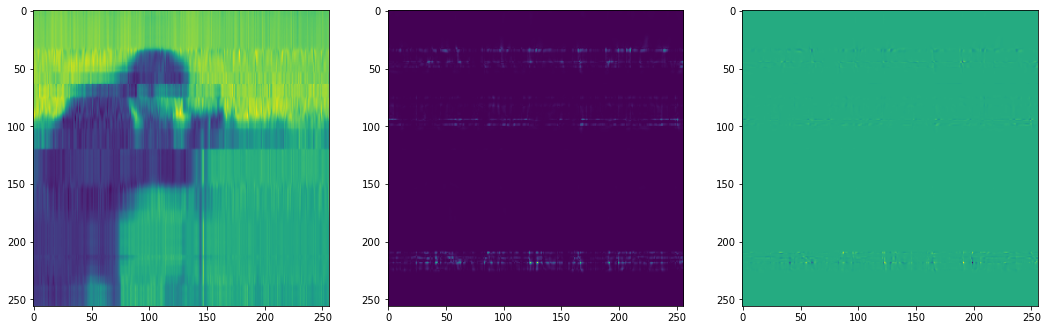

Step 210, Total loss 0.024866


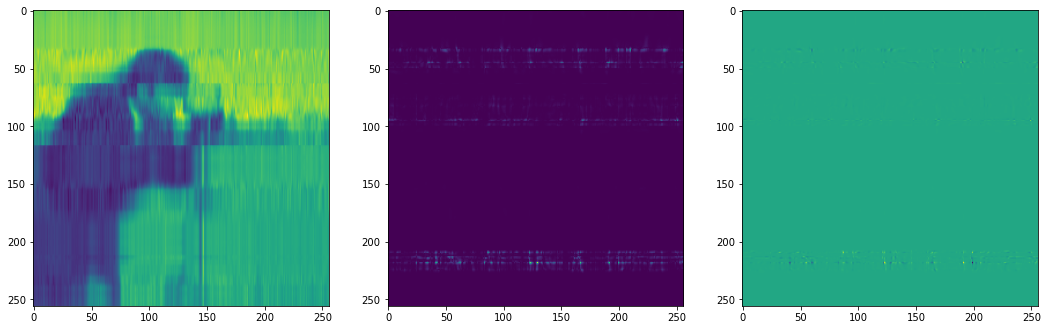

Step 220, Total loss 0.023623


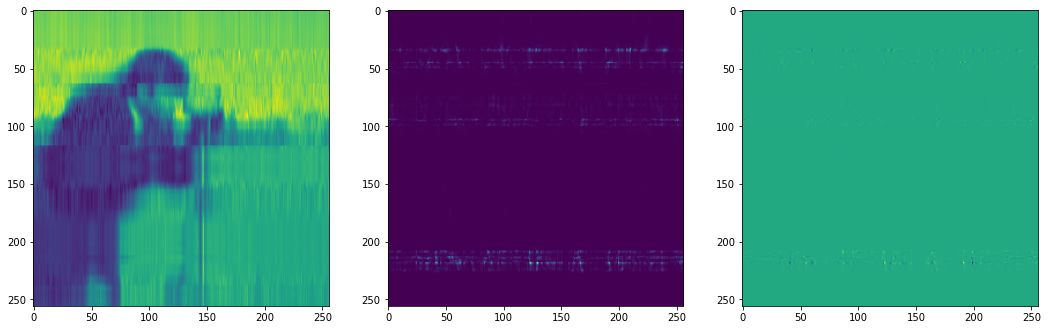

Step 230, Total loss 0.022655


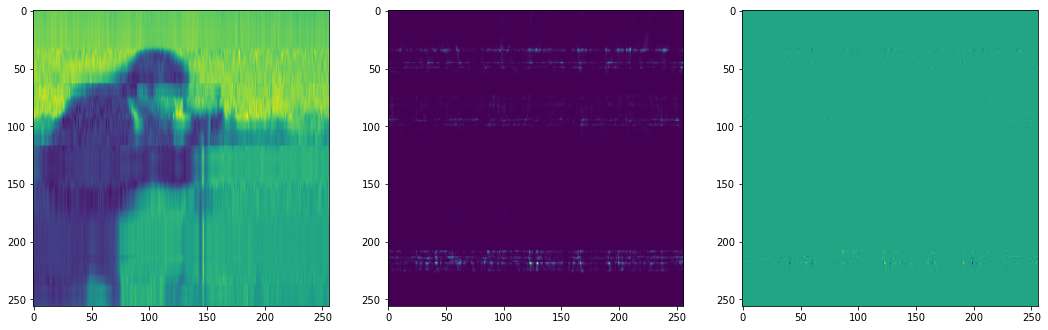

Step 240, Total loss 0.021813


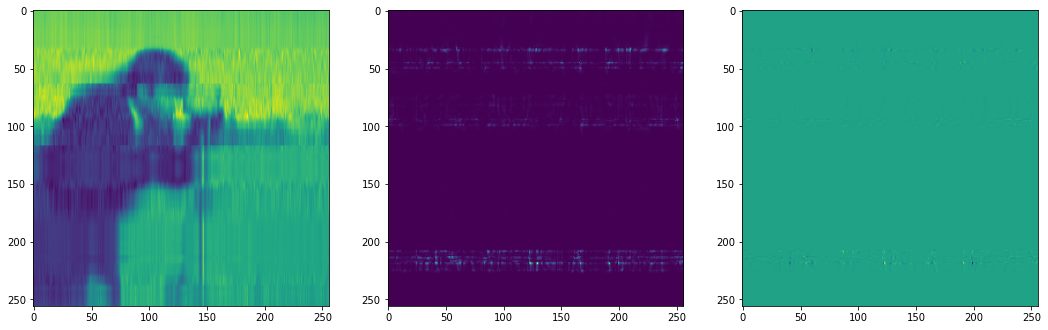

Step 250, Total loss 0.021049


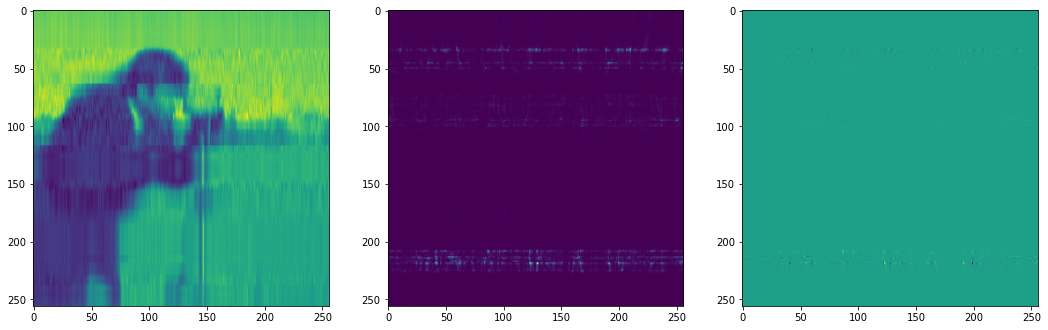

Step 260, Total loss 0.020289


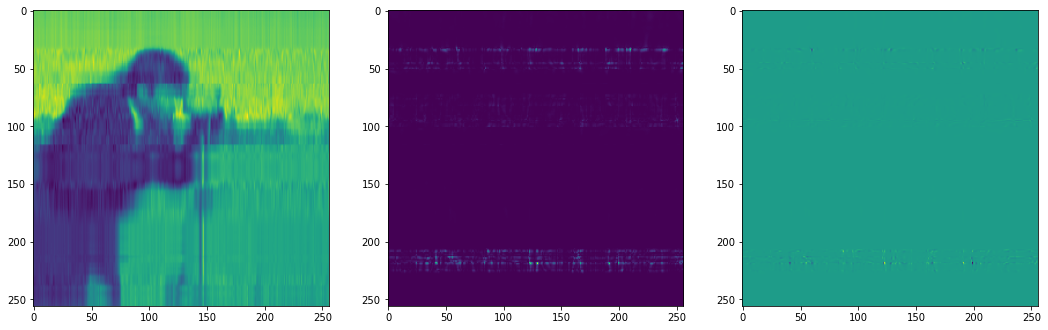

Step 270, Total loss 0.019591


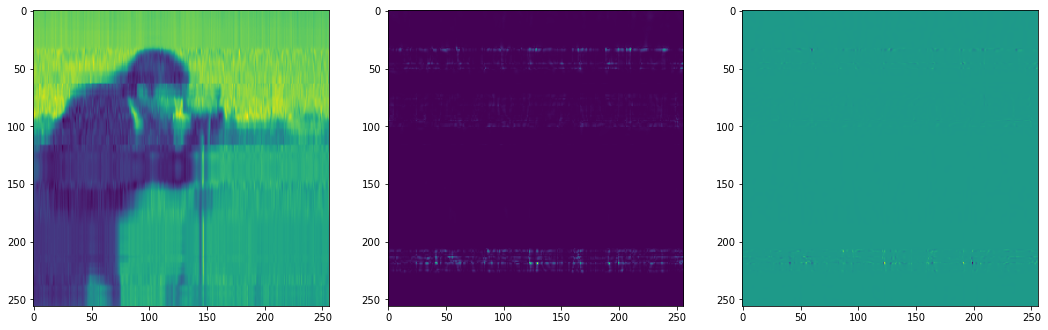

Step 280, Total loss 0.018969


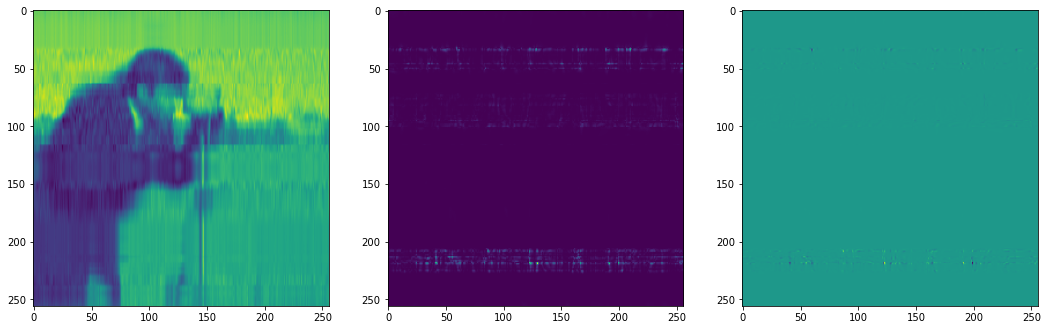

Step 290, Total loss 0.018455


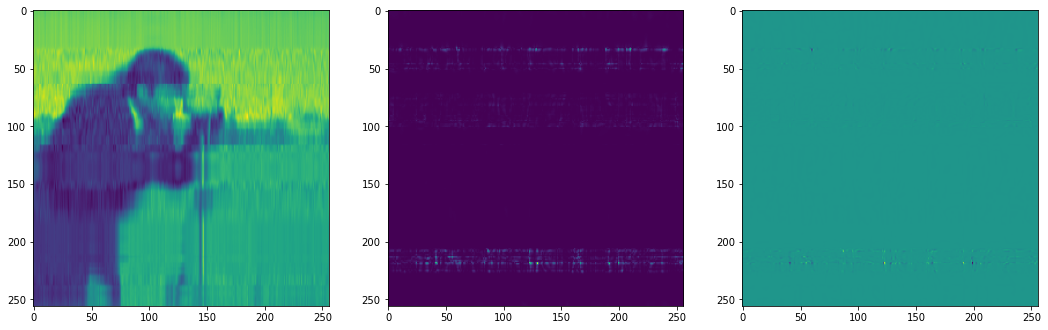

Step 300, Total loss 0.017843


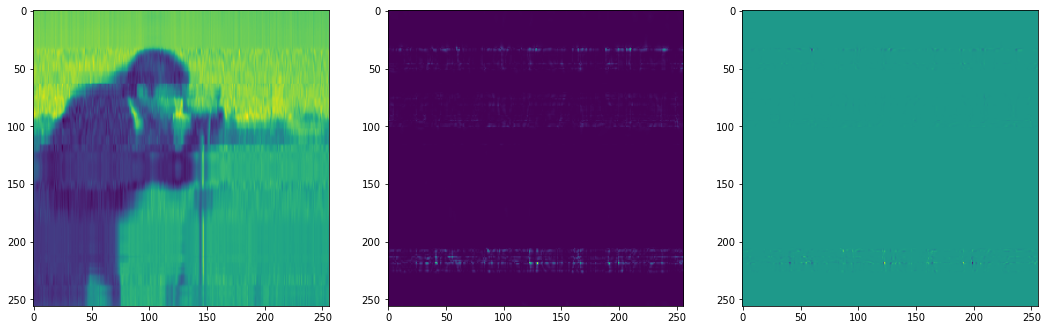

Step 310, Total loss 0.017559


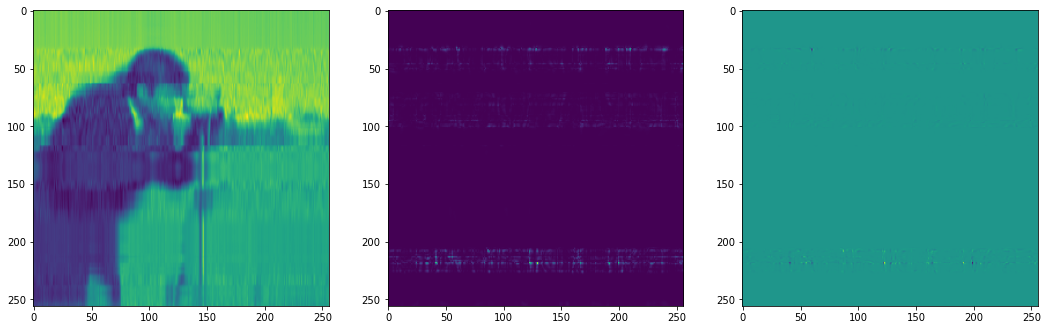

Step 320, Total loss 0.017033


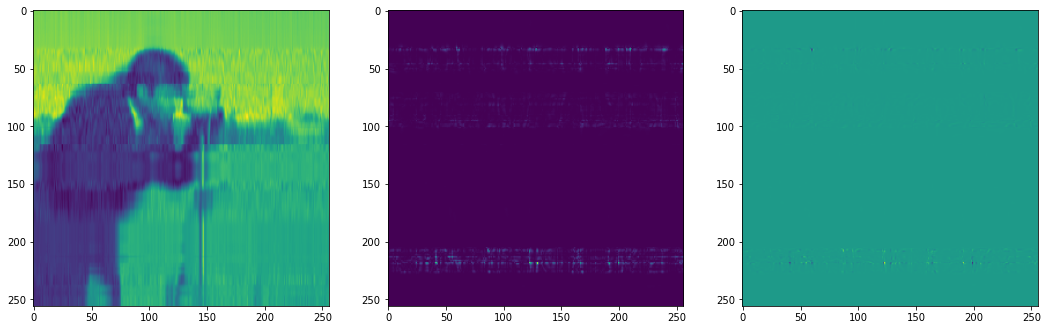

Step 330, Total loss 0.016464


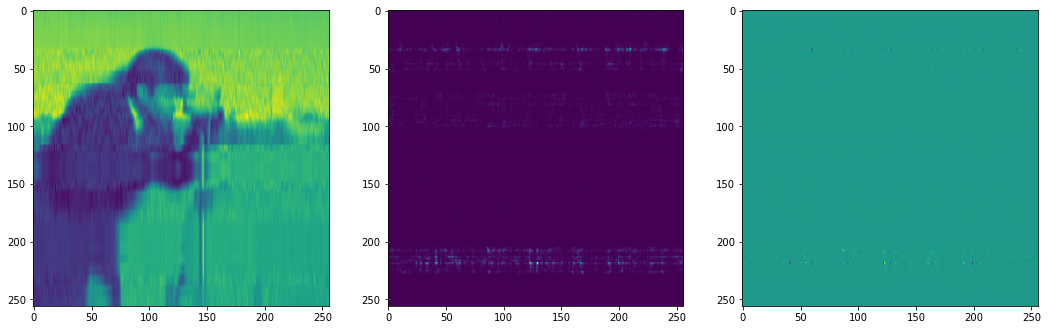

Step 340, Total loss 0.015947


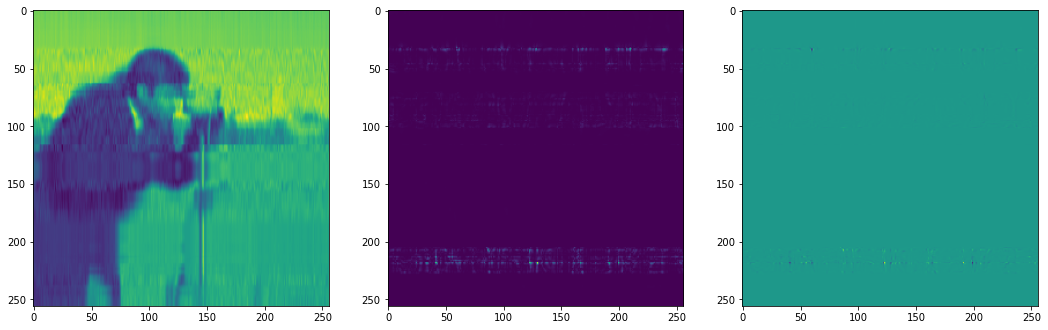

Step 350, Total loss 0.015513


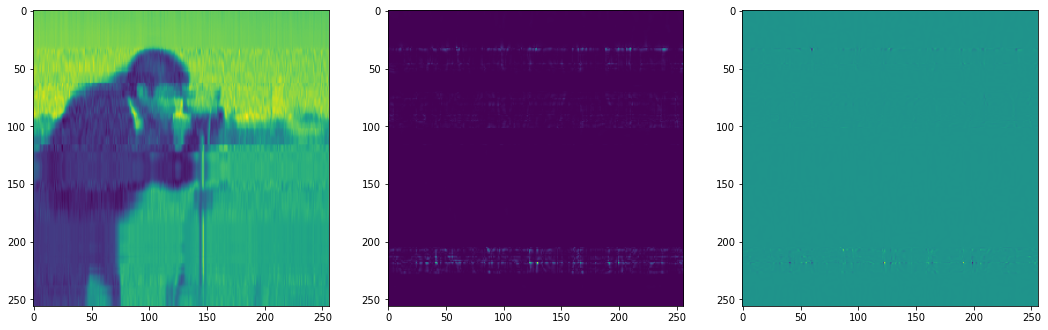

Step 360, Total loss 0.015119


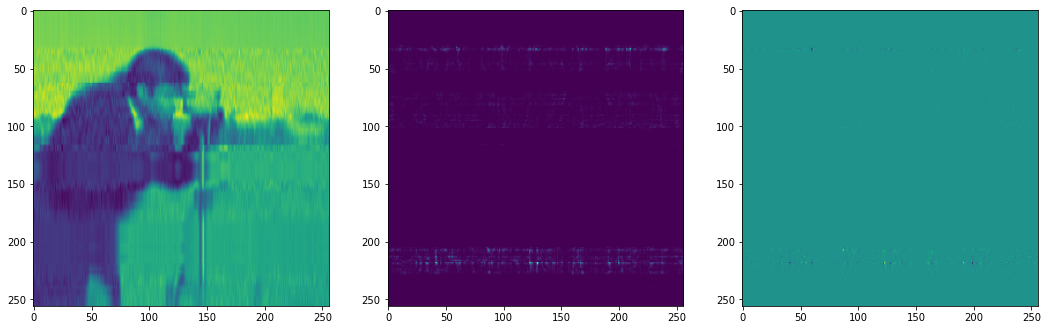

Step 370, Total loss 0.014696


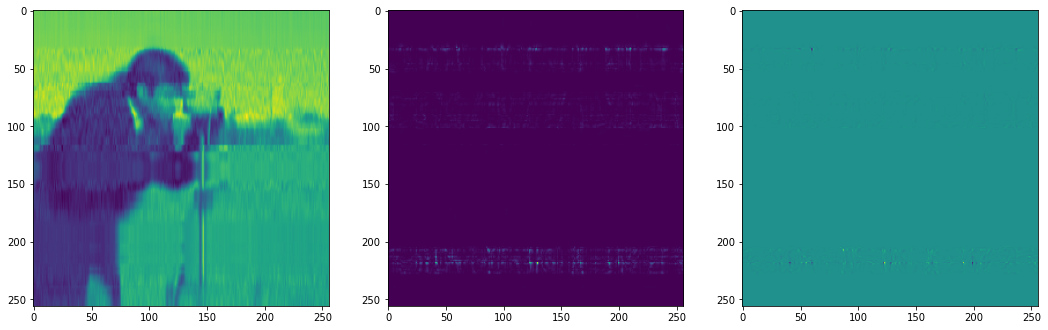

Step 380, Total loss 0.014407


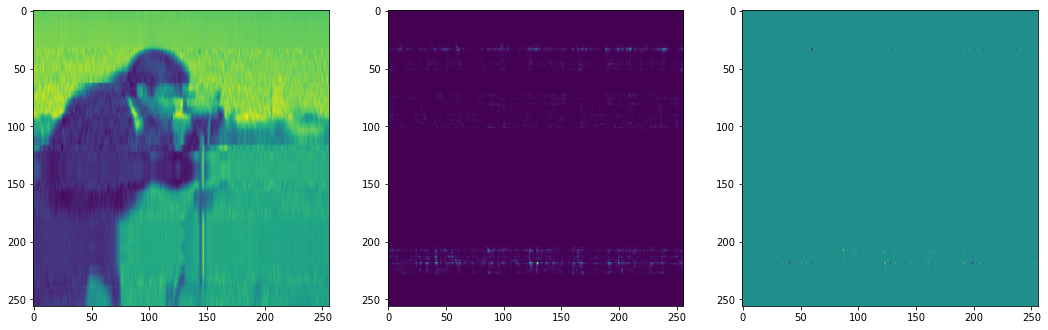

Step 390, Total loss 0.014149


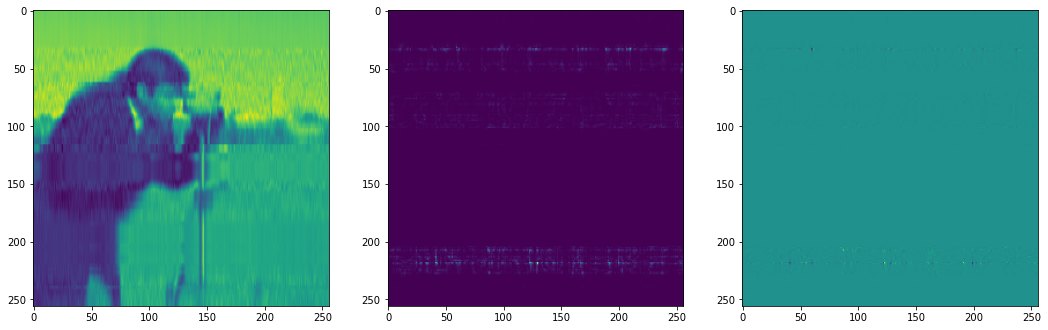

Step 400, Total loss 0.013770


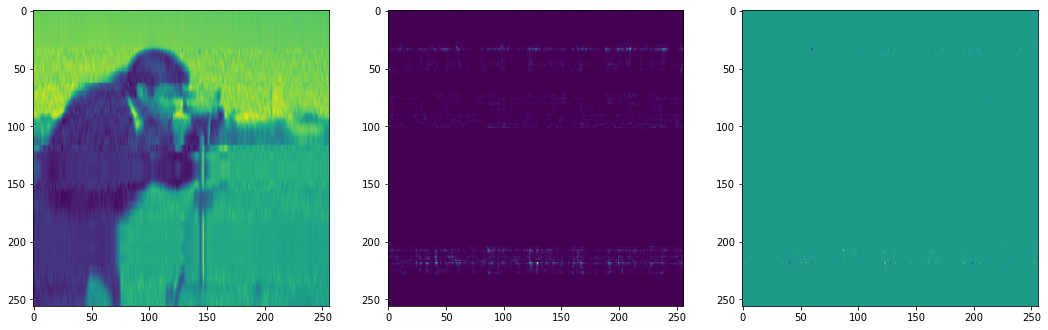

Step 410, Total loss 0.013502


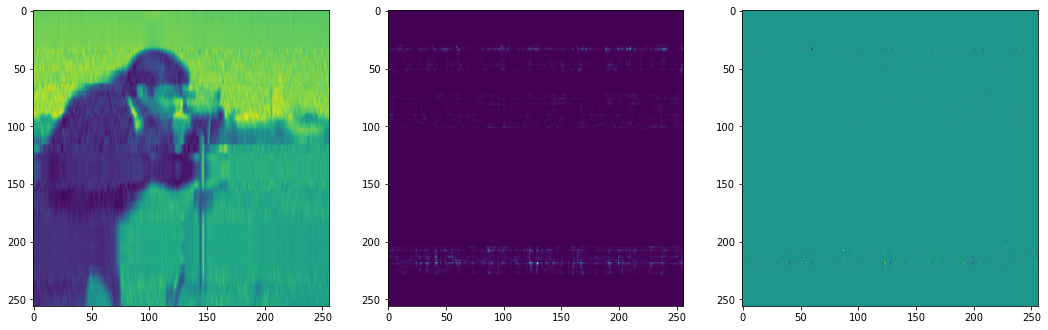

Step 420, Total loss 0.013129


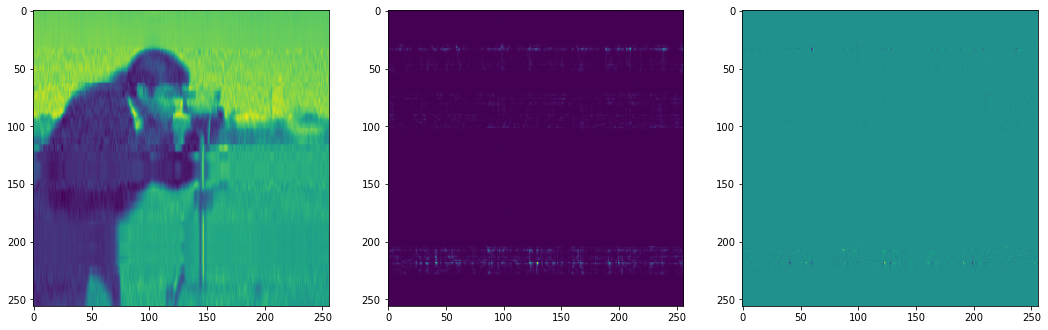

Step 430, Total loss 0.012778


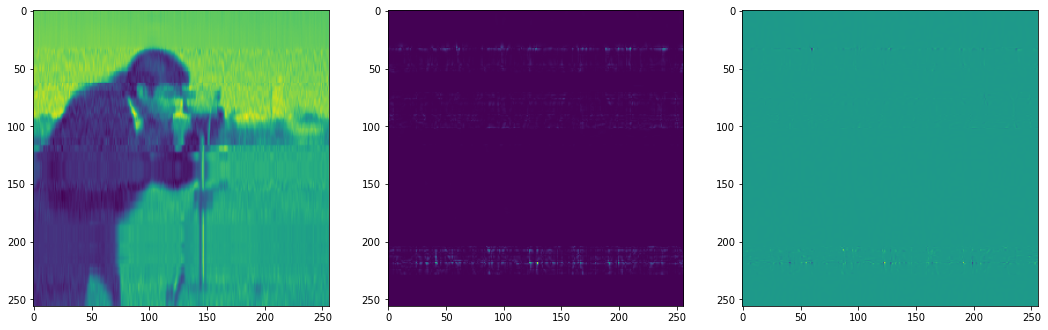

Step 440, Total loss 0.012500


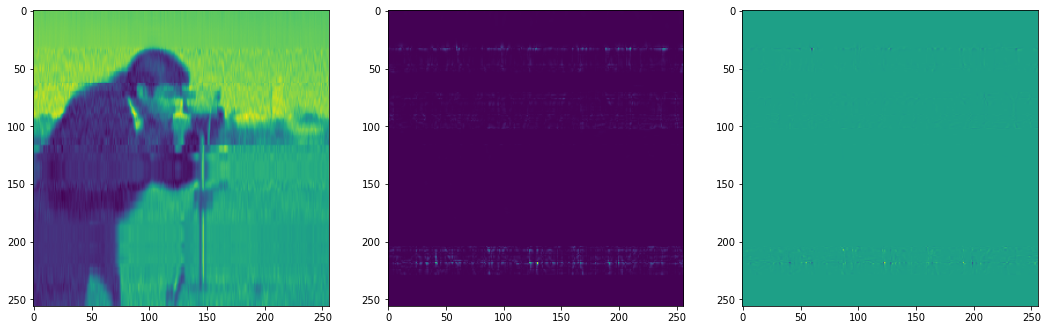

Step 450, Total loss 0.012504


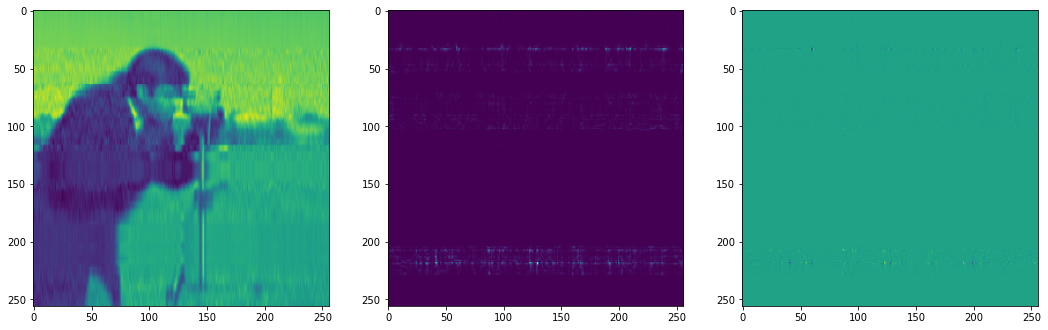

Step 460, Total loss 0.012320


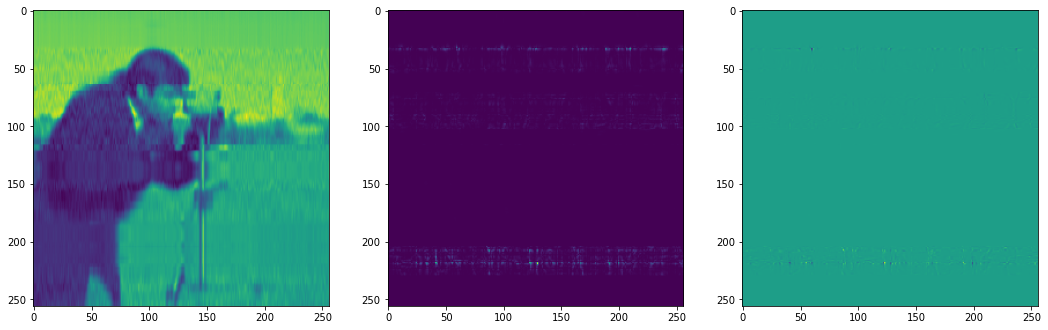

Step 470, Total loss 0.011758


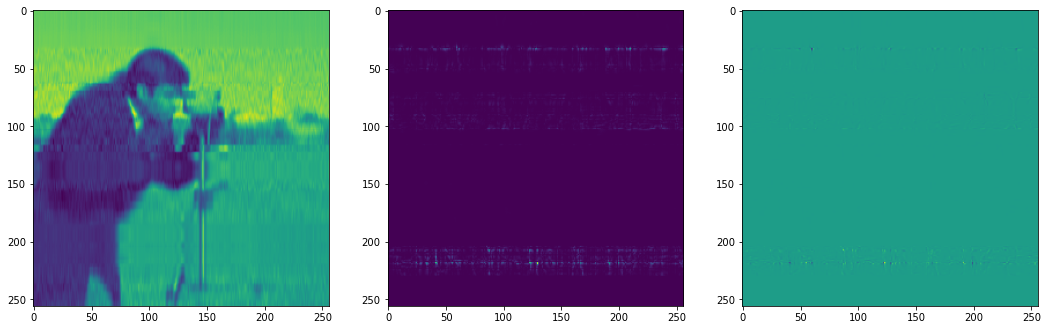

Step 480, Total loss 0.011483


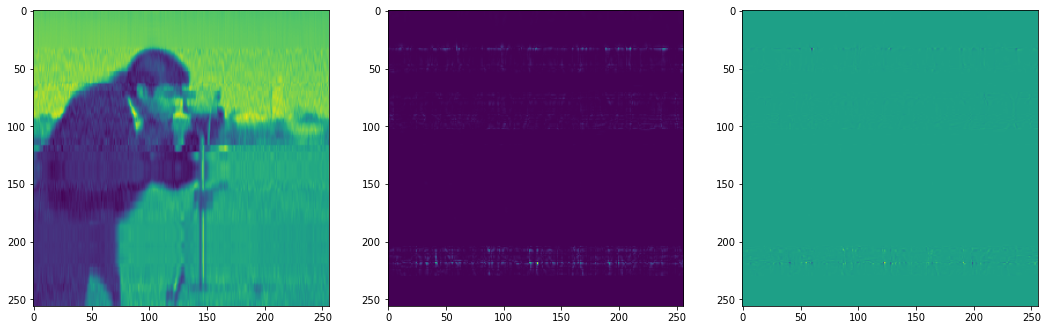

Step 490, Total loss 0.011420


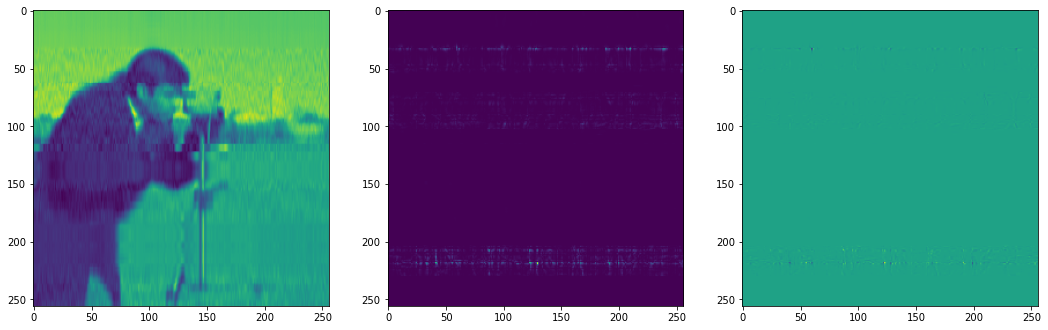

In [11]:
total_steps = 500
steps_til_summary = 10

optim = torch.optim.Adam(lr=1e-4, params=img_siren.parameters())

model_input, ground_truth = next(iter(dataloader))
model_input, ground_truth = model_input.to(device), ground_truth.to(device)

for step in range(total_steps):
    model_output, coords = img_siren(model_input)
    model_output = model_output.reshape(1, 65536, 1)
    loss = ((model_output - ground_truth)**2).mean()
    
    if not step % steps_til_summary:
        print("Step %d, Total loss %0.6f" % (step, loss))
        img_grad = gradient(model_output, coords)
        img_laplacian = laplace(model_output, coords)

        fig, axes = plt.subplots(1,3, figsize=(18,6))
        axes[0].imshow(model_output.cpu().view(256,256).detach().numpy())
        axes[1].imshow(img_grad.norm(dim=-1).cpu().view(256,256).detach().numpy())
        axes[2].imshow(img_laplacian.cpu().view(256,256).detach().numpy())
        plt.show()

    optim.zero_grad()
    loss.backward()
    optim.step()

### 6. Performance Evaluation

In [12]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Function to calculate PSNR (Peak Signal-to-Noise Ratio)
def calculate_psnr(img1, img2):
    img1_np = img1.detach().cpu().numpy()
    img2_np = img2.detach().cpu().numpy()
    data_range = float(max(img1_np.max()-img1_np.min(), img2_np.max()-img2_np.min(), img1_np.max()-img2_np.min(), img2_np.max()-img1_np.min()))
    psnr_value = peak_signal_noise_ratio(img1_np, img2_np, data_range=data_range)
    return psnr_value

# Function to calculate SSIM (Structural Similarity Index)
def calculate_ssim(img1, img2):
    img1_np = img1.detach().cpu().numpy().reshape(256, 256)
    img2_np = img2.detach().cpu().numpy().reshape(256, 256)
    ssim_value = structural_similarity(img1_np, img2_np)
    return ssim_value

PSNR = 26.365dB, SSIM = 0.654


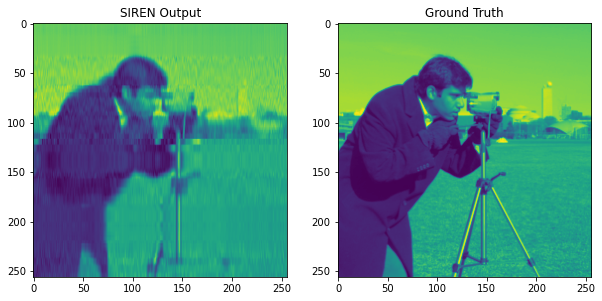

In [13]:
# Function to visualize evaluation
def visualize_evaluation(img1, img2):
    psnr_value = calculate_psnr(img1, img2)
    ssim_value = calculate_ssim(img1, img2)

    print(f"PSNR = {psnr_value:.3f}dB, SSIM = {ssim_value:.3f}")

    # Visualize images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img1.detach().cpu().numpy().reshape(256, 256))
    axes[0].set_title('SIREN Output')
    axes[1].imshow(img2.detach().cpu().numpy().reshape(256, 256))
    axes[1].set_title('Ground Truth')
    plt.show()
    
visualize_evaluation(model_output, ground_truth)